### Basic chatbot with langgraph

In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class state(TypedDict):
    #we use add messages after the every result the message is updated rather than
    messages:Annotated[list,add_messages]

In [3]:
import os
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")


In [4]:
llm = ChatGroq(model = "qwen/qwen3-32b")

In [5]:
llm = init_chat_model("groq:llama-3.3-70b-versatile")
llm

ChatGroq(output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002724EA7F110>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002724EA7FB10>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
def chatbot(state:state):
    return{"messages":[llm.invoke(state["messages"])]}

In [7]:
graph_builder = StateGraph(state)

graph_builder.add_node("llmchatbot",chatbot)

graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

##compile
graph = graph_builder.compile()

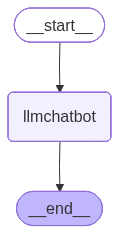

In [8]:
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
response = graph.invoke({"messages":"Hi"})


In [10]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [11]:
for event in graph.stream({"messages":"Hi,How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you might have. How about you? How's your day going?


### Tool

In [12]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [20]:
def search(a:int,b:int)->int:
    """Multiply a and b 
    
    Args:
        a (int):first int
        b (int):second int
        
    Returns:
        int:output int
    """
    

In [21]:
tools=[tool,search]

In [22]:
llm_with_tools = llm.bind_tools(tools)

In [23]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002724EA7F110>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002724EA7FB10>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for 

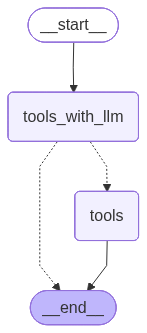

In [26]:
##State graph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

def tools_with_llm(state:state):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}
#Node
builder = StateGraph(state)
builder.add_node("tools_with_llm",tools_with_llm)
builder.add_node("tools",ToolNode(tools))

#edge
builder.add_edge(START,"tools_with_llm")
builder.add_conditional_edges("tools_with_llm",tools_condition)
builder.add_edge("tools",END)

##compile
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
response = graph.invoke({"messages":"How many centuries for virat kohli in international cricket?"})
response

{'messages': [HumanMessage(content='How many centuries for virat kohli in international cricket?', additional_kwargs={}, response_metadata={}, id='b639bd6b-ddf4-462a-9ffa-c36980a678aa'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'j35p35taj', 'function': {'arguments': '{"query":"Virat Kohli centuries in international cricket","search_depth":"basic","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 1758, 'total_tokens': 1794, 'completion_time': 0.112373295, 'completion_tokens_details': None, 'prompt_time': 0.096385928, 'prompt_tokens_details': None, 'queue_time': 0.311277567, 'total_time': 0.208759223}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eb618-335d-7982-8a91-8cf6a1665834-0', tool_calls=[{'name': 'tavily_search'

In [28]:
response["messages"][-1].content

'{"query": "Virat Kohli centuries in international cricket", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.reuters.com/sports/cricket/jaiswal-replaces-injured-kohli-odi-series-against-afghanistan-2026-06-06/", "title": "Jaiswal replaces injured Kohli for ODI series against Afghanistan - Reuters", "score": 0.36500442, "published_date": "Sat, 06 Jun 2026 08:53:43 GMT", "content": "# Jaiswal replaces injured Kohli for ODI series against Afghanistan. June 6 (Reuters) - India have called up Yashasvi Jaiswal to their squad for the three-match, one-day international \u200bseries against Afghanistan as a replacement for \u200cVirat Kohli, who has been ruled out due to injury, the country\'s cricket board (BCCI) said on Saturday. Veteran \u200bKohli, who has quit test cricket and \u200bT20 internationals, had been included in India\'s squad \u2060last month. However, he appeared to pick up \u200ba hamstring injury while playing for Royal Challengers

In [29]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

How many centuries for virat kohli in international cricket?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (j35p35taj)
 Call ID: j35p35taj
  Args:
    query: Virat Kohli centuries in international cricket
    search_depth: basic
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "Virat Kohli centuries in international cricket", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.reuters.com/sports/cricket/jaiswal-replaces-injured-kohli-odi-series-against-afghanistan-2026-06-06/", "title": "Jaiswal replaces injured Kohli for ODI series against Afghanistan - Reuters", "score": 0.36500442, "published_date": "Sat, 06 Jun 2026 08:53:43 GMT", "content": "# Jaiswal replaces injured Kohli for ODI series against Afghanistan. June 6 (Reut